In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import glob
import shutil

In [2]:
dataset_path = r"..\Dataset"
classes = [
    'im_Dyskeratotic', 
    'im_Koilocytotic', 
    'im_Metaplastic', 
    'im_Parabasal', 
    'im_Superficial-Intermediate'
]


Building the YOLO Dataset (Finding the Bounding Boxes)

In [3]:
processed_yolo_path = r"..\processed_data\yolo_dataset"

yolo_images_dir = os.path.join(processed_yolo_path, "images")
yolo_labels_dir = os.path.join(processed_yolo_path, "labels")

os.makedirs(yolo_images_dir, exist_ok=True)
os.makedirs(yolo_labels_dir, exist_ok=True)

In [4]:
for class_id, cell_class in enumerate(classes):
    print(f"Working on {cell_class}...")
    
    # Path to the raw uncropped images
    folder_path = os.path.join(dataset_path, cell_class, cell_class)
    image_files = glob.glob(os.path.join(folder_path, '*.bmp'))
    
    for img_path in image_files:
        
        img = cv2.imread(img_path)
        img_height, img_width = img.shape[:2]
        
        # Get the clean image name (Example: '001')
        image_name = os.path.basename(img_path).replace('.bmp', '')
        
        # Find all raw .dat coordinate files for this image
        dat_files = glob.glob(os.path.join(folder_path, f"{image_name}_cyt*.dat"))
        
        yolo_lines = [] 
        
        for dat_path in dat_files:
            x_dots, y_dots = [], []
            with open(dat_path, 'r') as f:
                for line in f:
                    parts = line.strip().split(',')
                    if len(parts) == 2:
                        x_dots.append(float(parts[0]))
                        y_dots.append(float(parts[1]))
            
            xmin, xmax = min(x_dots), max(x_dots)
            ymin, ymax = min(y_dots), max(y_dots)
            
            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            width = (xmax - xmin) / img_width
            height = (ymax - ymin) / img_height
            
            # Format: class x_center y_center width height
            yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")
            
        # 3. Only save if the image actually has cells in it
        if yolo_lines:
            # Save the YOLO .txt file into the clean 'labels' folder
            txt_save_path = os.path.join(yolo_labels_dir, f"{cell_class}_{image_name}.txt")
            with open(txt_save_path, 'w') as f:
                f.write('\n'.join(yolo_lines))
                
            # Copy the .bmp image into the clean 'images' folder
            # We rename it slightly so images from different classes don't overwrite each other!
            img_save_path = os.path.join(yolo_images_dir, f"{cell_class}_{image_name}.bmp")
            shutil.copy(img_path, img_save_path)

Working on im_Dyskeratotic...
Working on im_Koilocytotic...
Working on im_Metaplastic...
Working on im_Parabasal...
Working on im_Superficial-Intermediate...


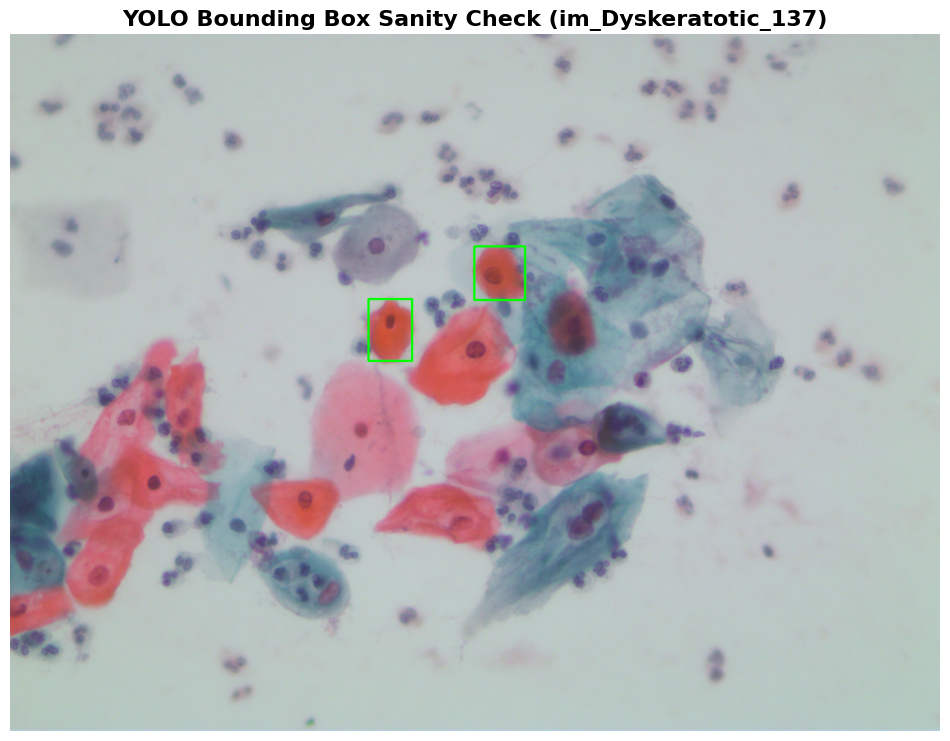

In [61]:
# Grab a random image from the YOLO dataset
yolo_images = glob.glob(r'..\processed_data\yolo_dataset\images\*.bmp')
if yolo_images:
    sample_img_path = random.choice(yolo_images)
    filename = os.path.basename(sample_img_path).replace('.bmp', '')
    
    # 2. Find its matching YOLO text label
    sample_label_path = os.path.join(r'..\processed_data\yolo_dataset\labels', filename + '.txt')
    
    # 3. Load the Image
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img.shape[:2]
    
    # 4. Reverse the YOLO math to draw the boxes
    with open(sample_label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            
            # YOLO format is normalized percentages. Multiply by image size to get pixels!
            x_center = float(parts[1]) * img_width
            y_center = float(parts[2]) * img_height
            width = float(parts[3]) * img_width
            height = float(parts[4]) * img_height
            
            # Find the top-left (xmin, ymin) and bottom-right (xmax, ymax) corners
            xmin = int(x_center - (width / 2))
            ymin = int(y_center - (height / 2))
            xmax = int(x_center + (width / 2))
            ymax = int(y_center + (height / 2))
            
            # 5. Draw a thick green rectangle
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 4)
    
    # 6. Plot it!
    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.title(f'YOLO Bounding Box Sanity Check ({filename})', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("No YOLO images found.")

Building the U-Net Dataset (Drawing the Masks)

In [8]:
processed_unet_path = r"..\processed_data\unet_dataset"

unet_images_dir = os.path.join(processed_unet_path, "images")
unet_masks_dir = os.path.join(processed_unet_path, "masks")

os.makedirs(unet_images_dir, exist_ok=True)
os.makedirs(unet_masks_dir, exist_ok=True)

In [9]:
def read_polygon(dat_path):
    """Reads a .dat file and returns a list of [x, y] coordinates."""
    points = []
    if os.path.exists(dat_path):
        with open(dat_path, 'r') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) == 2:
                    points.append([float(parts[0]), float(parts[1])])
    return points

In [10]:
for cell_class in classes:
    print(f"Working on {cell_class}...")
    
    # Notice we are looking in the CROPPED folders this time!
    cropped_folder = os.path.join(dataset_path, cell_class, cell_class, 'CROPPED')
    image_files = glob.glob(os.path.join(cropped_folder, '*.bmp'))
    
    for img_path in image_files:
        # Read image to get its exact size
        img = cv2.imread(img_path)
        img_height, img_width = img.shape[:2]
        
        image_name = os.path.basename(img_path).replace('.bmp', '')
        
        # Paths to the raw .dat files
        cyt_dat_path = os.path.join(cropped_folder, f"{image_name}_cyt.dat")
        nuc_dat_path = os.path.join(cropped_folder, f"{image_name}_nuc.dat")
        
        cyt_points = read_polygon(cyt_dat_path)
        nuc_points = read_polygon(nuc_dat_path)
        
        if not cyt_points:
            continue # Skip if no data
            
        # 3. Mathematical Shift
        # Find the top-left corner of the cytoplasm to use as our "zero" point
        x_coords = [p[0] for p in cyt_points]
        y_coords = [p[1] for p in cyt_points]
        offset_x = min(x_coords)
        offset_y = min(y_coords)
        
        # Shift all coordinates by that offset
        shifted_cyt = [[int(x - offset_x), int(y - offset_y)] for x, y in cyt_points]
        shifted_nuc = [[int(x - offset_x), int(y - offset_y)] for x, y in nuc_points]
        
        # 4. Draw the Mask
        # Create a completely black image (zeros)
        mask = np.zeros((img_height, img_width), dtype=np.uint8)
        
        # Draw Cytoplasm as GRAY (128)
        if shifted_cyt:
            pts_cyt = np.array(shifted_cyt, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [pts_cyt], 128)
            
        # Draw Nucleus as WHITE (255) right on top of the cytoplasm
        if shifted_nuc:
            pts_nuc = np.array(shifted_nuc, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [pts_nuc], 255)
            
        # 5. Save files to our clean folder!
        new_name = f"{cell_class}_{image_name}"
        shutil.copy(img_path, os.path.join(unet_images_dir, f"{new_name}.bmp"))
        cv2.imwrite(os.path.join(unet_masks_dir, f"{new_name}.png"), mask)

Working on im_Dyskeratotic...
Working on im_Koilocytotic...
Working on im_Metaplastic...
Working on im_Parabasal...
Working on im_Superficial-Intermediate...


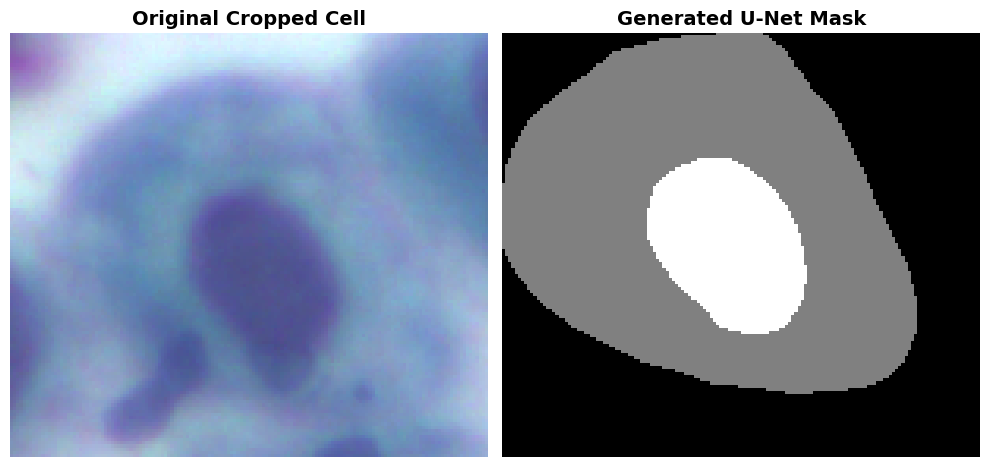

In [ ]:
# Grab a random image from the U-Net dataset we just created
unet_images = glob.glob(r'..\processed_data\unet_dataset\images\*.bmp')
if unet_images:
    sample_img_path = random.choice(unet_images)
    filename = os.path.basename(sample_img_path).replace('.bmp', '')
    
    # 2. Find its matching mask
    sample_mask_path = os.path.join(r'..\processed_data\unet_dataset\masks', filename + '.png')
    
    # 3. Load the Image and the Mask
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Fix colors for Matplotlib
    mask = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 4. Plot them side-by-side!
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img)
    axes[0].set_title('Original Cropped Cell', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Generated U-Net Mask', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No U-Net images found.")

Building the CNN Dataset

In [62]:
processed_cnn_path = r"..\processed_data\cnn_dataset"

In [63]:
for cell_class in classes:
    print(f"Copying {cell_class} images...")
    
    # Create the clean class folder (e.g. cnn_dataset/im_Dyskeratotic)
    class_save_dir = os.path.join(processed_cnn_path, cell_class)
    os.makedirs(class_save_dir, exist_ok=True)
    
    # Find the original cropped images
    cropped_folder = os.path.join(dataset_path, cell_class, cell_class, 'CROPPED')
    image_files = glob.glob(os.path.join(cropped_folder, '*.bmp'))
    
    # Copy them over to the new clean folder!
    for img_path in image_files:
        image_name = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(class_save_dir, image_name))

Copying im_Dyskeratotic images...
Copying im_Koilocytotic images...
Copying im_Metaplastic images...
Copying im_Parabasal images...
Copying im_Superficial-Intermediate images...
